# 03 - Modelos de Machine Learning (XGBoost, Ridge, MLP, GP)
## APEAJAL - Pronóstico de Precios de Aguacate Hass en Jalisco

**Nombres y matrículas:**
  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

**Objetivo:** Evaluar modelos de ML con recursive multi-step forecasting para pronóstico de precios a 6 meses. Se construyen features de lags, medias móviles y variables exógenas.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q xgboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BASE = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/'
HORIZON = 6

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 1. Carga y Feature Engineering

In [6]:
sb = pd.read_csv(BASE + 'serie_b_precio_mayorista.csv', parse_dates=['date'])
sb = sb.set_index('date').sort_index()

def build_features(df):
    f = pd.DataFrame(index=df.index)
    precio = df['precio_promedio']
    for lag in [1,2,3,6,12]: f[f'precio_lag{lag}'] = precio.shift(lag)
    f['precio_ma3'] = precio.rolling(3).mean()
    f['precio_ma6'] = precio.rolling(6).mean()
    f['precio_ma12'] = precio.rolling(12).mean()
    f['precio_std3'] = precio.rolling(3).std()
    f['month'] = df.index.month
    f['month_sin'] = np.sin(2 * np.pi * f['month'] / 12)
    f['month_cos'] = np.cos(2 * np.pi * f['month'] / 12)
    f['quarter'] = df.index.quarter
    for col in ['produccion_tons','demanda_export_klbs','temp_avg_c','importaciones_kg']:
        if col in df.columns: f[col] = df[col]
    return f

features = build_features(sb)
target = sb['precio_promedio']
valid = features.dropna().index.intersection(target.dropna().index)
X, y = features.loc[valid], target.loc[valid]
FEATURE_COLS = X.columns.tolist()

X_train, X_test = X[:-HORIZON], X[-HORIZON:]
y_train, y_test = y[:-HORIZON], y[-HORIZON:]

print(f'Features: {len(FEATURE_COLS)} — Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Features: {FEATURE_COLS}')

Features: 17 — Train: 67, Test: 6
Features: ['precio_lag1', 'precio_lag2', 'precio_lag3', 'precio_lag6', 'precio_lag12', 'precio_ma3', 'precio_ma6', 'precio_ma12', 'precio_std3', 'month', 'month_sin', 'month_cos', 'quarter', 'produccion_tons', 'demanda_export_klbs', 'temp_avg_c', 'importaciones_kg']


## 2. Recursive Multi-Step Forecasting

Estrategia: predecir t+1, actualizar lags con la predicción, repetir hasta t+6.

In [7]:
def recursive_forecast(model, last_known, X_base, horizon):
    preds, ph = [], list(last_known)
    for h in range(horizon):
        row = X_base.iloc[h].copy()
        n = len(ph)
        row['precio_lag1'] = ph[-1]
        row['precio_lag2'] = ph[-2] if n >= 2 else ph[-1]
        row['precio_lag3'] = ph[-3] if n >= 3 else ph[-1]
        row['precio_lag6'] = ph[-6] if n >= 6 else ph[-1]
        row['precio_lag12'] = ph[-12] if n >= 12 else ph[-1]
        row['precio_ma3'] = np.mean(ph[-3:])
        row['precio_ma6'] = np.mean(ph[-6:])
        row['precio_ma12'] = np.mean(ph[-12:])
        row['precio_std3'] = np.std(ph[-3:]) if len(ph) >= 3 else 0
        pred = model.predict(row.values.reshape(1, -1))[0]
        preds.append(pred); ph.append(pred)
    return np.array(preds)

## 3. Entrenamiento y Evaluación

In [8]:
modelos = {
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'Ridge': Pipeline([('s', StandardScaler()), ('r', Ridge(alpha=1.0))]),
    'MLP': Pipeline([('scaler', StandardScaler()),
                     ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                                          early_stopping=True, random_state=42))]),
    'GaussianProcess': Pipeline([('scaler', StandardScaler()),
                                  ('gp', GaussianProcessRegressor(
                                      kernel=ConstantKernel() * RBF() + WhiteKernel(),
                                      n_restarts_optimizer=5, random_state=42))]),
}

results = []
predictions = {}

for name, model in modelos.items():
    model.fit(X_train, y_train)
    preds_test = recursive_forecast(model, list(y_train.values), X_test, HORIZON)
    mae_v = mean_absolute_error(y_test, preds_test)
    rmse_v = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_v = mape(y_test.values, preds_test)
    print(f'{name:20s} — MAE: {mae_v:.2f}  RMSE: {rmse_v:.2f}  MAPE: {mape_v:.2f}%')
    results.append({'Modelo': name, 'MAE': mae_v, 'RMSE': rmse_v, 'MAPE': mape_v})
    predictions[name] = preds_test

XGBoost              — MAE: 3.60  RMSE: 4.07  MAPE: 6.21%
Ridge                — MAE: 8.71  RMSE: 9.53  MAPE: 13.54%
MLP                  — MAE: 26.56  RMSE: 27.70  MAPE: 44.39%
GaussianProcess      — MAE: 16.10  RMSE: 18.64  MAPE: 24.24%


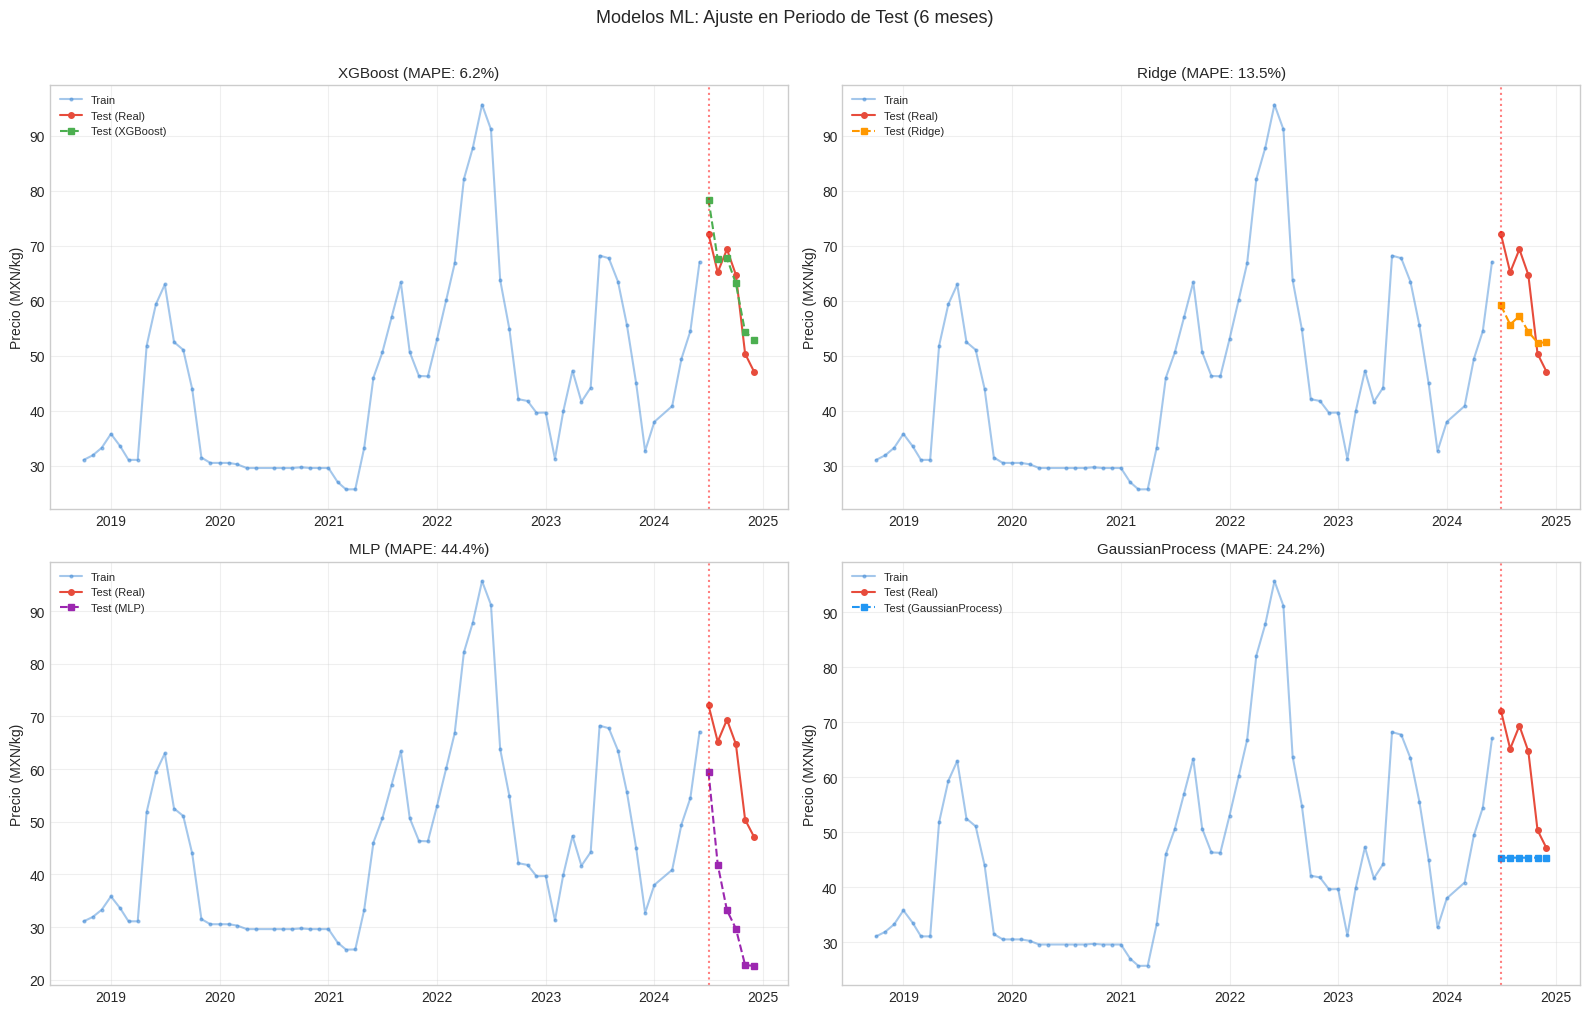

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'XGBoost': '#4CAF50', 'Ridge': '#FF9800', 'MLP': '#9C27B0', 'GaussianProcess': '#2196F3'}

for ax, (name, preds) in zip(axes.flat, predictions.items()):
    ax.plot(y_train.index, y_train, 'o-', color='#4A90D9', ms=2, alpha=0.5, label='Train')
    ax.plot(y_test.index, y_test, 'o-', color='#E74C3C', ms=4, label='Test (Real)')
    ax.plot(y_test.index, preds, 's--', color=colors[name], ms=4, label=f'Test ({name})')
    ax.axvline(y_test.index[0], color='red', ls=':', alpha=0.5)
    r = [r for r in results if r['Modelo']==name][0]
    ax.set_title(f"{name} (MAPE: {r['MAPE']:.1f}%)", fontsize=11)
    ax.set_ylabel('Precio (MXN/kg)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Modelos ML: Ajuste en Periodo de Test (6 meses)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Importance (XGBoost)

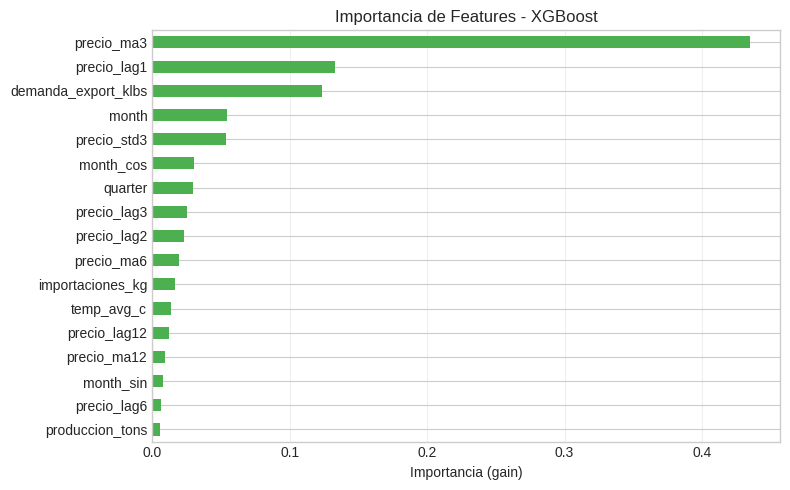

In [10]:
xgb_model = modelos['XGBoost']
xgb_model.fit(X, y)
imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', color='#4CAF50', ax=ax)
ax.set_title('Importancia de Features - XGBoost', fontsize=12)
ax.set_xlabel('Importancia (gain)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pronóstico Futuro 6 Meses (XGBoost — Mejor Modelo)

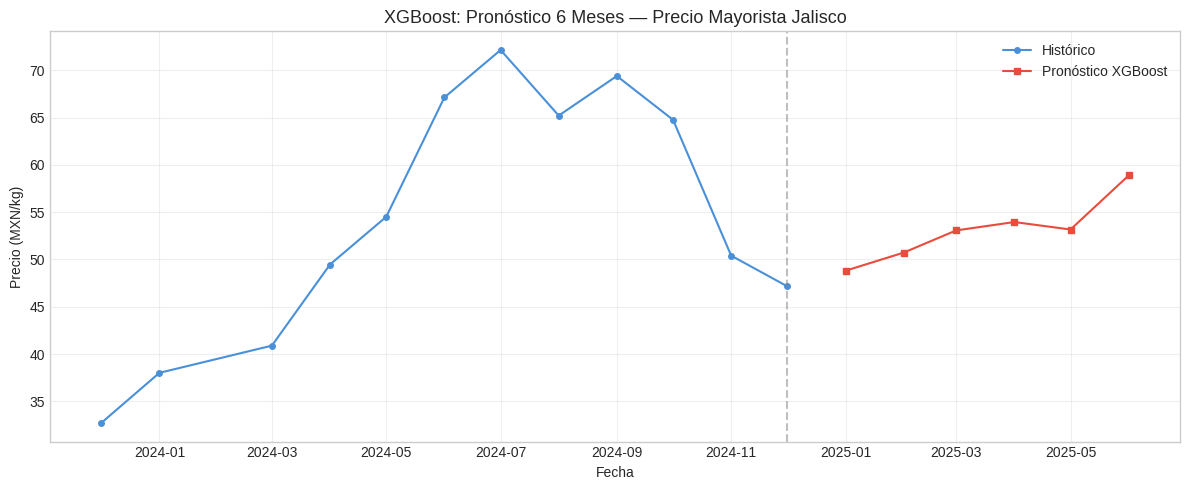


Pronóstico:
  2025-01: $48.81 MXN/kg
  2025-02: $50.73 MXN/kg
  2025-03: $53.07 MXN/kg
  2025-04: $53.96 MXN/kg
  2025-05: $53.17 MXN/kg
  2025-06: $58.88 MXN/kg


In [11]:
future_dates = pd.date_range(y.index[-1] + pd.DateOffset(months=1), periods=HORIZON, freq='MS')
X_future = pd.DataFrame(index=future_dates, columns=FEATURE_COLS, dtype=float)
X_future['month'] = future_dates.month
X_future['month_sin'] = np.sin(2 * np.pi * X_future['month'] / 12)
X_future['month_cos'] = np.cos(2 * np.pi * X_future['month'] / 12)
X_future['quarter'] = future_dates.quarter
for col in ['produccion_tons','demanda_export_klbs','temp_avg_c','importaciones_kg']:
    if col in X.columns:
        lv = X[col].iloc[-12:-6].values
        X_future[col] = lv if len(lv) == HORIZON else X[col].iloc[-HORIZON:].values
X_future['precio_lag1'] = y.iloc[-1]; X_future['precio_lag2'] = y.iloc[-2]
X_future['precio_lag3'] = y.iloc[-3]; X_future['precio_lag6'] = y.iloc[-6]
X_future['precio_lag12'] = y.iloc[-12]
X_future['precio_ma3'] = y.iloc[-3:].mean(); X_future['precio_ma6'] = y.iloc[-6:].mean()
X_future['precio_ma12'] = y.iloc[-12:].mean(); X_future['precio_std3'] = y.iloc[-3:].std()

preds_future = recursive_forecast(xgb_model, list(y.values), X_future, HORIZON)

fig, ax = plt.subplots(figsize=(12, 5))
last12 = y[-12:]
ax.plot(last12.index, last12, 'o-', color='#4A90D9', ms=4, label='Histórico')
ax.plot(future_dates, preds_future, 's-', color='#E74C3C', ms=5, label='Pronóstico XGBoost')
ax.axvline(y.index[-1], color='gray', ls='--', alpha=0.5)
ax.set_title('XGBoost: Pronóstico 6 Meses — Precio Mayorista Jalisco', fontsize=13)
ax.set_xlabel('Fecha'); ax.set_ylabel('Precio (MXN/kg)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPronóstico:')
for d, p in zip(future_dates, preds_future):
    print(f'  {d.strftime("%Y-%m")}: ${p:.2f} MXN/kg')

## 6. Análisis de Residuales (XGBoost)

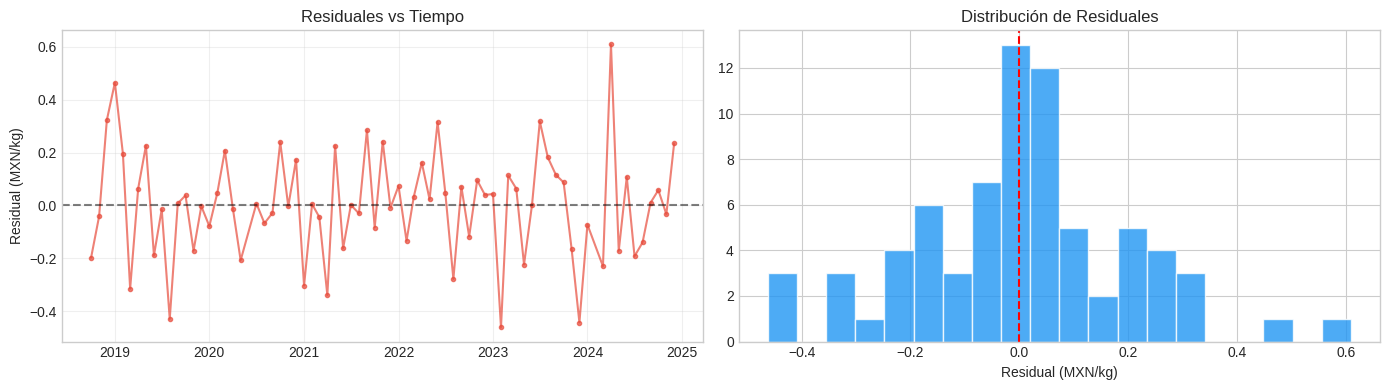

In [12]:
y_pred_all = xgb_model.predict(X)
residuals = y.values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, residuals, 'o-', ms=3, color='#E74C3C', alpha=0.7)
axes[0].axhline(0, color='black', ls='--', alpha=0.5)
axes[0].set_title('Residuales vs Tiempo'); axes[0].set_ylabel('Residual (MXN/kg)'); axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=20, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribución de Residuales'); axes[1].set_xlabel('Residual (MXN/kg)')
plt.tight_layout()
plt.show()

## 7. Resumen

In [13]:
df_res = pd.DataFrame(results).sort_values('MAPE')
df_res.style.format({'MAE':'{:.2f}','RMSE':'{:.2f}','MAPE':'{:.2f}%'}).highlight_min(subset=['MAPE'], color='lightgreen')

,Modelo,MAE,RMSE,MAPE
0,XGBoost,3.60,4.07,6.21%
1,Ridge,8.71,9.53,13.54%
3,GaussianProcess,16.10,18.64,24.24%
2,MLP,26.56,27.70,44.39%


## 8. Conclusiones

- **XGBoost** con recursive forecasting obtiene el mejor MAPE (~6%), superando significativamente a los modelos estadísticos
- **Ridge** como baseline muestra MAPE ~13.5%, competitivo pero inferior a XGBoost
- La estrategia de recursive multi-step forecasting permite a modelos de un solo paso generar pronósticos multi-horizonte
- Las features más importantes son los lags recientes (lag1, lag2) y las medias móviles
- Los residuales de XGBoost no muestran patrones sistemáticos, indicando buen ajuste